# ML Basket 5: Kalman Filter Beta Classification (High vs Low Beta)

## Overview
This Jupyter Notebook constructs ML-ready portfolios by classifying factors into HIGH_BETA_KALMAN (offensive) and LOW_BETA_KALMAN (defensive) categories using Kalman Filter time-varying CAPM beta estimates. It dynamically selects top/bottom 50% of factors by beta, computes equal-weighted returns and turnovers, and generates aggregated baskets for machine learning applications.

## Key Features
- **Beta Estimation**: Kalman Filter CAPM betas (process variance Q=0.0001, auto-estimated observation variance) for 25 factors.
- **Dynamic Selection**: Monthly rebalancing based on lagged betas (no lookahead bias).
- **Portfolio Construction**: Equal-weighted aggregation of HIGH_BETA_KALMAN and LOW_BETA_KALMAN portfolios.
- **Turnover Calculation**: Dynamic turnover metrics for transaction cost analysis.
- **Visualization**: Cumulative returns plots with CAGR stats.

## Methodology
1. Load factor excess returns, compute Kalman Filter betas using CAPM.
2. Rank factors by lagged beta, select top/bottom 50% for HIGH_BETA_KALMAN/LOW_BETA_KALMAN.
3. Aggregate into dynamic portfolios (EW gross returns).
4. Compute turnovers and allocations.
5. Save baskets, allocations; generate plots.

## Dependencies
- Libraries: pandas, numpy, matplotlib, pathlib.
- Data: Signal Parquet files, NYSE P20 benchmark, FF5 factors.
- Environment: macOS with VS Code, Python 3.x.

## Usage
1. Adjust FEATURES_BASELINE if needed.
2. Run cells to load data, compute betas, construct portfolios, and save outputs.
3. Review saved Parquet files and cumulative returns plots.

## Output Files
- **data/ml_data/baskets/basket_5_beta_kalman.parquet**: Parquet with Market, HIGH_BETA_KALMAN, LOW_BETA_KALMAN returns, and aggregated turnovers.
- **data/ml_data/baskets/allocations/basket_5_allocations.parquet**: Parquet with monthly allocations for HIGH_BETA_KALMAN and LOW_BETA_KALMAN.

This notebook prepares Kalman Filter beta-based baskets for ML modeling, ensuring dynamic factor selection and academic rigor.

In [1]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 1 : IMPORTS
# ════════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
from pathlib import Path
from typing import Dict, Tuple
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
pd.set_option('display.precision', 4)

print("="*100)
print("📦 NOTEBOOK 5 : KALMAN FILTER BETA STRATEGY")
print("="*100)
print("✅ Imports loaded")
print("="*100)

📦 NOTEBOOK 5 : KALMAN FILTER BETA STRATEGY
✅ Imports loaded


In [2]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 2 : LOAD DATA
# ════════════════════════════════════════════════════════════════════════════

print("="*100)
print("📦 CHARGEMENT DES DONNÉES")
print("="*100)

FEATURES_BASELINE = {
    # ────────────────────────────────────────────────────────────────────────
    # 1. PROFITABILITY (5 factors) - Theory: Novy-Marx (2013), Fama-French
    # ────────────────────────────────────────────────────────────────────────
    'gross_profitability': 'P10',       # High GP/AT = Strong pricing power (Novy-Marx 2013)
    'operating_profitability': 'P10',   # High OP/AT = Quality (Fama-French 2015)
    'return_on_assets': 'P10',          # High ROA = Profitability (DuPont analysis)
    'change_asset_turnover': 'P10',     # Improving turnover = Efficiency gains
    'change_profit_margin': 'P10',      # Improving margin = Competitive advantage
    
    # ────────────────────────────────────────────────────────────────────────
    # 2. INVESTMENT (6 factors) - Theory: Cooper et al. (2008), Titman et al.
    # ────────────────────────────────────────────────────────────────────────
    'roic': 'P10',                      # HIGH ROIC = Capital efficiency (Brown & Rowe 2007)
    'asset_growth': 'P1',               # LOW asset growth = No empire building (Cooper 2008)
    'investment_capex': 'P1',           # LOW CapEx = Conservative (Titman 2004)
    'capex_inventory_growth': 'P1',     # LOW combined growth = Quality
    'net_share_issues': 'P1',           # LOW dilution = Shareholder-friendly (Pontiff 2008)
    'capex_growth': 'P1',               # LOW CapEx growth = Sustainable
    'sales_growth': 'P1',               # LOW sales growth = Avoid over-expansion (Lakonishok)
    
    # ────────────────────────────────────────────────────────────────────────
    # 3. ACCRUALS & QUALITY (4 factors) - Theory: Sloan (1996), Richardson
    # ────────────────────────────────────────────────────────────────────────
    'working_capital_accruals': 'P1',   # LOW accruals = High earnings quality (Sloan 1996)
    'sales_receivables_gap': 'P10',     # HIGH gap = Real demand (vs channel stuffing)
    'receivables_turnover': 'P10',      # HIGH turnover = Fast collection (credit quality)
    'operating_leverage': 'P10',        # HIGH sales-inventory gap = Real growth
    
    # ────────────────────────────────────────────────────────────────────────
    # 4. LIQUIDITY & SOLVENCY (5 factors) - Theory: Altman Z-score, Piotroski
    # ────────────────────────────────────────────────────────────────────────
    'cash_cushion': 'P10',              # HIGH cash/assets = Financial flexibility
    'debt_capacity': 'P10',             # HIGH debt capacity = Strong tangible base (Almeida 2007)
    'book_leverage': 'P1',              # LOW leverage = Safety (Bhandari 1988 reversal)
    'change_current_ratio': 'P10',      # Improving liquidity = Reduced distress risk
    
    # ────────────────────────────────────────────────────────────────────────
    # 5. OPERATING EFFICIENCY (5 factors) - Theory: Asset pricing, Efficiency
    # ────────────────────────────────────────────────────────────────────────
    'asset_turnover': 'P10',            # HIGH asset turnover = Revenue generation efficiency
    'cash_productivity': 'P10',         # HIGH sales/cash = Efficient cash deployment
    'depreciation_to_ppe': 'P1',        # LOW depreciation = Younger assets (less wear)
    'change_depreciation': 'P1',        # LOW Δ depreciation = Stable asset base
    'tax_income_ratio': 'P10',          # HIGH tax efficiency = Retention quality
}


def load_factor_returns(features_config: Dict[str, str], 
                       data_dir: Path = Path('data/portfolios')) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Load factor returns and compute excess returns for CAPM beta estimation.
    
    Returns:
    --------
    df_returns_EXCESS : pd.DataFrame
        Factor EXCESS returns (R - RF) + Market excess return (for beta calculation)
    df_returns_GROSS : pd.DataFrame
        Factor GROSS returns (for portfolio construction)
    """
    
    returns_dict_excess = {}
    returns_dict_gross = {}
    
    # STEP 1: Load NYSE P20 Benchmark
    nyse_p20_path = Path('data/ml_data/market/market_returns_ew_nys80.parquet')
    
    if not nyse_p20_path.exists():
        print(f"⚠️  NYSE P20 benchmark not found. Please run 06_1 first.")
        raise FileNotFoundError(f"Missing {nyse_p20_path}")
    
    df_nyse_p20 = pd.read_parquet(nyse_p20_path)
    df_nyse_p20['date'] = pd.to_datetime(df_nyse_p20['date'])
    df_nyse_p20 = df_nyse_p20.set_index('date')
    
    market_ret_gross = df_nyse_p20['ret_market_ew'].copy()
    
    # STEP 2: Load RF (Fama-French)
    ff_path = Path('data/factors/ff/FF5.csv')
    df_ff = pd.read_csv(ff_path)
    df_ff['dateff'] = pd.to_datetime(df_ff['dateff'])
    df_ff = df_ff.set_index('dateff')
    
    rf = df_ff['rf']  # Already in decimal
    
    # STEP 3: Load Factor Returns and Calculate Excess
    for factor, leg in features_config.items():
        signal_path = data_dir / f'{factor}_signal.parquet'
        
        if not signal_path.exists():
            continue
        
        signal_df = pd.read_parquet(signal_path)
        signal_df['date'] = pd.to_datetime(signal_df['date'])
        signal_df = signal_df.set_index('date')
        
        if leg == 'P10':
            factor_ret_gross = signal_df['ret_high_ew']
        else:
            factor_ret_gross = signal_df['ret_low_ew']
        
        # GROSS returns (for portfolio construction)
        returns_dict_gross[factor] = factor_ret_gross
        
        # EXCESS returns (for beta calculation)
        common_dates = factor_ret_gross.index.intersection(rf.index)
        factor_ret_excess = factor_ret_gross.loc[common_dates] - rf.loc[common_dates]
        returns_dict_excess[factor] = factor_ret_excess
    
    # STEP 4: Construct DataFrames
    df_returns_gross = pd.DataFrame(returns_dict_gross)
    df_returns_excess = pd.DataFrame(returns_dict_excess)
    
    # Market excess return (for beta calculation)
    common_dates_mkt = market_ret_gross.index.intersection(rf.index)
    market_ret_excess = market_ret_gross.loc[common_dates_mkt] - rf.loc[common_dates_mkt]
    market_ret_excess = market_ret_excess.reindex(df_returns_excess.index)
    
    df_returns_excess.insert(0, 'Market', market_ret_excess)
    
    return df_returns_excess, df_returns_gross

# Load data (EXCESS for beta, GROSS for portfolios)
df_returns_EXCESS, df_returns_GROSS = load_factor_returns(FEATURES_BASELINE)

print(f"\n✅ Data loaded:")
print(f"   • EXCESS returns (for beta): {df_returns_EXCESS.shape}")
print(f"   • GROSS returns (for portfolios): {df_returns_GROSS.shape}")
print(f"   • Period: {df_returns_EXCESS.index.min().date()} → {df_returns_EXCESS.index.max().date()}")

print("\n" + "="*100)

📦 CHARGEMENT DES DONNÉES

✅ Data loaded:
   • EXCESS returns (for beta): (738, 26)
   • GROSS returns (for portfolios): (738, 25)
   • Period: 1963-07-31 → 2024-12-31



In [4]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 3 : KALMAN FILTER IMPLEMENTATION
# ════════════════════════════════════════════════════════════════════════════

print("="*100)
print("📈 KALMAN FILTER BETA COMPUTATION")
print("="*100)

def kalman_filter_beta(factor_returns: pd.Series, 
                      market_returns: pd.Series,
                      Q: float = 0.0001,
                      R: float = None,
                      min_periods: int = 60) -> Tuple[pd.Series, pd.Series]:
    """
    Compute time-varying beta using Kalman Filter.
    
    State-Space Model:
    ------------------
    STATE EQUATION:
        β_t = β_{t-1} + η_t,    η_t ~ N(0, Q)
    
    OBSERVATION EQUATION:
        R_i,t = α + β_t × R_market,t + ε_t,    ε_t ~ N(0, R)
    
    Kalman Filter Recursion:
    ------------------------
    1. PREDICT:
       β_t|t-1 = β_{t-1|t-1}
       P_t|t-1 = P_{t-1|t-1} + Q
    
    2. UPDATE:
       K_t = P_t|t-1 × R_market,t / (R_market,t² × P_t|t-1 + R)
       β_t|t = β_t|t-1 + K_t × (R_i,t - β_t|t-1 × R_market,t)
       P_t|t = (1 - K_t × R_market,t) × P_t|t-1
    
    Parameters:
    -----------
    factor_returns : pd.Series
    market_returns : pd.Series
    Q : float
        Process variance (state equation noise)
        Higher Q → More reactive beta
        Typical: 0.0001 (monthly), 0.001 (more adaptive)
    R : float
        Observation variance (measurement noise)
        If None: estimated from residuals of initial OLS
    min_periods : int
        Minimum observations for OLS initialization
    
    Returns:
    --------
    beta_filtered : pd.Series
        Filtered beta estimates (β_t|t)
    beta_variance : pd.Series
        Posterior variance (P_t|t) - uncertainty measure
    
    Reference:
    ----------
    Faff & Hillier (2005), Wells (1994)
    """
    
    # Align series
    merged = pd.concat([factor_returns, market_returns], axis=1).dropna()
    merged.columns = ['factor', 'market']
    
    T = len(merged)
    
    if T < min_periods:
        return pd.Series(np.nan, index=merged.index), pd.Series(np.nan, index=merged.index)
    
    # ═══════════════════════════════════════════════════════════════════════
    # INITIALIZATION: OLS on first min_periods observations
    # ═══════════════════════════════════════════════════════════════════════
    
    y_init = merged['factor'].iloc[:min_periods].values
    X_init = merged['market'].iloc[:min_periods].values
    
    # OLS: β_0 = (X'X)^(-1) X'y
    beta_0 = np.sum(X_init * y_init) / np.sum(X_init ** 2)
    
    # Initial state variance (OLS standard error squared)
    residuals_init = y_init - beta_0 * X_init
    if R is None:
        R = np.var(residuals_init)  # Observation variance
    
    P_0 = np.var(residuals_init) / np.sum(X_init ** 2)  # Initial state variance
    
    # ═══════════════════════════════════════════════════════════════════════
    # KALMAN FILTER RECURSION
    # ═══════════════════════════════════════════════════════════════════════
    
    beta_filtered = np.full(T, np.nan)
    beta_variance = np.full(T, np.nan)
    
    # Set initial values
    beta_filtered[:min_periods] = beta_0
    beta_variance[:min_periods] = P_0
    
    beta_t = beta_0  # Current state estimate
    P_t = P_0        # Current state variance
    
    for t in range(min_periods, T):
        y_t = merged['factor'].iloc[t]
        X_t = merged['market'].iloc[t]
        
        # ───────────────────────────────────────────────────────────────────
        # PREDICT STEP
        # ───────────────────────────────────────────────────────────────────
        beta_predict = beta_t  # Random walk: E[β_t | β_{t-1}] = β_{t-1}
        P_predict = P_t + Q    # Var[β_t | β_{t-1}] = Var[β_{t-1}] + Q
        
        # ───────────────────────────────────────────────────────────────────
        # UPDATE STEP
        # ───────────────────────────────────────────────────────────────────
        
        # Innovation (forecast error)
        innovation = y_t - beta_predict * X_t
        
        # Innovation variance
        S_t = X_t**2 * P_predict + R
        
        # Kalman Gain
        K_t = (P_predict * X_t) / S_t
        
        # Updated state estimate
        beta_t = beta_predict + K_t * innovation
        
        # Updated state variance
        P_t = (1 - K_t * X_t) * P_predict
        
        # Store
        beta_filtered[t] = beta_t
        beta_variance[t] = P_t
    
    # Convert to Series
    beta_series = pd.Series(beta_filtered, index=merged.index)
    variance_series = pd.Series(beta_variance, index=merged.index)
    
    return beta_series, variance_series


def compute_all_kalman_betas(df_returns: pd.DataFrame, 
                             Q: float = 0.0001,
                             R: float = None,
                             min_periods: int = 60) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Compute Kalman Filter betas for all factors.
    """
    
    market_ret = df_returns['Market']
    factor_names = [col for col in df_returns.columns if col != 'Market']
    
    betas_dict = {}
    variances_dict = {}
    
    print(f"🔄 Computing Kalman Filter betas for {len(factor_names)} factors...")
    print(f"   • Process variance (Q)     : {Q}")
    print(f"   • Observation variance (R) : {'Auto-estimated' if R is None else R}")
    print(f"   • Min periods              : {min_periods} months")
    print(f"\n   📊 Model specification:")
    print(f"      STATE:       β_t = β_{{t-1}} + η_t,  η_t ~ N(0, {Q})")
    print(f"      OBSERVATION: R_i,t = β_t × R_market,t + ε_t")
    
    for i, factor in enumerate(factor_names, 1):
        beta, variance = kalman_filter_beta(df_returns[factor], market_ret, Q, R, min_periods)
        betas_dict[factor] = beta
        variances_dict[factor] = variance
        
        if i % 5 == 0:
            print(f"      ... {i}/{len(factor_names)} factors processed")
    
    df_betas = pd.DataFrame(betas_dict)
    df_variances = pd.DataFrame(variances_dict)
    
    return df_betas, df_variances

# ════════════════════════════════════════════════════════════════════════════
# COMPUTE KALMAN BETAS
# ════════════════════════════════════════════════════════════════════════════

Q_VARIANCE = 0.0001  # Process variance (lower = smoother, higher = more reactive)
R_VARIANCE = None    # Auto-estimated from OLS residuals
MIN_PERIODS = 60     # 5 years initialization

df_betas_kalman, df_variances_kalman = compute_all_kalman_betas(
    df_returns_EXCESS, 
    Q=Q_VARIANCE, 
    R=R_VARIANCE, 
    min_periods=MIN_PERIODS
)
print(f"\n✅ Kalman Filter betas computed :")
print(f"   • Shape      : {df_betas_kalman.shape}")
print(f"   • Valid from : {df_betas_kalman.dropna(how='all').index.min().date()}")
print(f"   • Missing    : {df_betas_kalman.isnull().sum().sum()}")

print(f"\n📊 Latest betas (sorted) :")
latest_betas = df_betas_kalman.iloc[-1].dropna().sort_values()
print(f"\n   🔽 Lowest (Defensive) :")
print(latest_betas.head(5).to_string())
print(f"\n   🔼 Highest (Offensive) :")
print(latest_betas.tail(5).to_string())

print(f"\n📊 Average posterior variance (uncertainty) :")
avg_variance = df_variances_kalman.mean().sort_values()
print(f"\n   🎯 Most stable (lowest variance) :")
print(avg_variance.head(3).to_string())

print("\n" + "="*100)

📈 KALMAN FILTER BETA COMPUTATION
🔄 Computing Kalman Filter betas for 25 factors...
   • Process variance (Q)     : 0.0001
   • Observation variance (R) : Auto-estimated
   • Min periods              : 60 months

   📊 Model specification:
      STATE:       β_t = β_{t-1} + η_t,  η_t ~ N(0, 0.0001)
      OBSERVATION: R_i,t = β_t × R_market,t + ε_t
      ... 5/25 factors processed
      ... 10/25 factors processed
      ... 15/25 factors processed
      ... 20/25 factors processed
      ... 25/25 factors processed

✅ Kalman Filter betas computed :
   • Shape      : (732, 25)
   • Valid from : 1963-07-31
   • Missing    : 12

📊 Latest betas (sorted) :

   🔽 Lowest (Defensive) :
investment_capex     0.8821
cash_productivity    0.9331
cash_cushion         0.9639
book_leverage        0.9717
tax_income_ratio     0.9928

   🔼 Highest (Offensive) :
asset_growth             1.1402
change_asset_turnover    1.1528
sales_growth             1.1530
operating_leverage       1.1584
receivables_turnover 

In [6]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 4 : PORTFOLIO CONSTRUCTION
# ════════════════════════════════════════════════════════════════════════════

print("="*100)
print("🏗️  CONSTRUCTION DES PORTFOLIOS (KALMAN BETA)")
print("="*100)

def construct_beta_portfolios(df_returns_EXCESS: pd.DataFrame,
                              df_returns_GROSS: pd.DataFrame,
                              df_betas: pd.DataFrame,
                              top_pct: float = 0.5) -> Tuple[pd.Series, pd.Series, pd.DataFrame]:
    """
    Parameters:
    -----------
    df_returns_EXCESS : For context only
    df_returns_GROSS : USED for portfolio returns (GROSS)
    df_betas : Beta estimates (computed from EXCESS returns)
    """
    
    n_factors = len(df_betas.columns)
    n_select = int(n_factors * top_pct)
    
    print(f"🎯 Parameters:")
    print(f"   • Factors per basket: {n_select} ({top_pct*100:.0f}%)")
    
    high_beta_returns = []
    low_beta_returns = []
    high_alloc_list = []
    low_alloc_list = []
    
    df_betas_lagged = df_betas.shift(1)
    dates = df_betas_lagged.dropna(how='all').index
    
    print(f"\n🔄 Constructing portfolios for {len(dates)} months...")
    print(f"   ⚠️  TIMING: Using beta_{{t-1}} (lagged) for formation, ret_t for holding")
    
    for date in dates:
        betas_t_minus_1 = df_betas_lagged.loc[date].dropna()
        
        if len(betas_t_minus_1) < n_select * 2:
            high_beta_returns.append(np.nan)
            low_beta_returns.append(np.nan)
            high_alloc_list.append(pd.Series(0, index=df_betas.columns))
            low_alloc_list.append(pd.Series(0, index=df_betas.columns))
            continue
        
        betas_sorted = betas_t_minus_1.sort_values()
        low_beta_factors = betas_sorted.head(n_select).index.tolist()
        high_beta_factors = betas_sorted.tail(n_select).index.tolist()
        
        if date not in df_returns_GROSS.index:
            high_beta_returns.append(np.nan)
            low_beta_returns.append(np.nan)
            high_alloc_list.append(pd.Series(0, index=df_betas.columns))
            low_alloc_list.append(pd.Series(0, index=df_betas.columns))
            continue
        
        returns_t_GROSS = df_returns_GROSS.loc[date, df_betas.columns]
        
        high_ret = returns_t_GROSS[high_beta_factors].mean()
        low_ret = returns_t_GROSS[low_beta_factors].mean()
        
        high_beta_returns.append(high_ret)
        low_beta_returns.append(low_ret)
        
        high_alloc = pd.Series(0, index=df_betas.columns)
        high_alloc[high_beta_factors] = 1
        high_alloc_list.append(high_alloc)
        
        low_alloc = pd.Series(0, index=df_betas.columns)
        low_alloc[low_beta_factors] = 1
        low_alloc_list.append(low_alloc)
    
    high_beta_ret = pd.Series(high_beta_returns, index=dates, name='HIGH_BETA_KALMAN')
    low_beta_ret = pd.Series(low_beta_returns, index=dates, name='LOW_BETA_KALMAN')
    
    allocations = pd.concat({
        'HIGH_BETA': pd.DataFrame(high_alloc_list, index=dates),
        'LOW_BETA': pd.DataFrame(low_alloc_list, index=dates)
    }, axis=1)
    
    return high_beta_ret, low_beta_ret, allocations


Portfolio_High_Kalman, Portfolio_Low_Kalman, allocations_kalman = construct_beta_portfolios(
    df_returns_EXCESS,
    df_returns_GROSS,
    df_betas_kalman,
    0.5
)

print(f"\n✅ Portfolios constructed :")
print(f"   • Valid from : {Portfolio_High_Kalman.dropna().index.min().date()}")
print(f"   • Months     : {len(Portfolio_High_Kalman.dropna())}")

print("\n" + "="*100)

🏗️  CONSTRUCTION DES PORTFOLIOS (KALMAN BETA)
🎯 Parameters:
   • Factors per basket: 12 (50%)

🔄 Constructing portfolios for 731 months...
   ⚠️  TIMING: Using beta_{t-1} (lagged) for formation, ret_t for holding

✅ Portfolios constructed :
   • Valid from : 1963-08-30
   • Months     : 731



In [7]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 5 : CONSTRUCTION DES PORTFOLIOS + TURNOVER
# ════════════════════════════════════════════════════════════════════════════

print("="*100)
print("🏗️  CONSTRUCTION DES PORTFOLIOS DYNAMIQUES (KALMAN BETA)")
print("="*100)

Portfolio_High_Kalman, Portfolio_Low_Kalman, allocations_kalman = construct_beta_portfolios(
    df_returns_EXCESS,
    df_returns_GROSS,
    df_betas_kalman,
    0.5
)

print(f"\n✅ Portfolios constructed:")
print(f"   • HIGH_BETA_KALMAN: {len(Portfolio_High_Kalman.dropna())} months")
print(f"   • LOW_BETA_KALMAN: {len(Portfolio_Low_Kalman.dropna())} months")
print(f"   • Valid from: {Portfolio_High_Kalman.dropna().index.min().date()}")

# ════════════════════════════════════════════════════════════════════════════
# CALCUL DU TURNOVER
# ════════════════════════════════════════════════════════════════════════════

print("\n" + "="*100)
print("🔄 CALCUL DU TURNOVER")
print("="*100)

def compute_turnover(allocations: pd.DataFrame, basket_name: str) -> pd.Series:
    alloc = allocations[basket_name]
    alloc_shifted = alloc.shift(1)
    changes = (alloc - alloc_shifted).abs()
    turnover = changes.sum(axis=1) / 2
    return turnover

Turnover_High_Kalman = compute_turnover(allocations_kalman, 'HIGH_BETA')
Turnover_Low_Kalman = compute_turnover(allocations_kalman, 'LOW_BETA')

print(f"\n✅ Turnover computed:")
print(f"   • HIGH_BETA: Mean {Turnover_High_Kalman.mean()*100:.2f}%, Annualized {Turnover_High_Kalman.mean()*1200:.0f}%")
print(f"   • LOW_BETA: Mean {Turnover_Low_Kalman.mean()*100:.2f}%, Annualized {Turnover_Low_Kalman.mean()*1200:.0f}%")

print("\n" + "="*100)


🏗️  CONSTRUCTION DES PORTFOLIOS DYNAMIQUES (KALMAN BETA)
🎯 Parameters:
   • Factors per basket: 12 (50%)

🔄 Constructing portfolios for 731 months...
   ⚠️  TIMING: Using beta_{t-1} (lagged) for formation, ret_t for holding

✅ Portfolios constructed:
   • HIGH_BETA_KALMAN: 731 months
   • LOW_BETA_KALMAN: 731 months
   • Valid from: 1963-08-30

🔄 CALCUL DU TURNOVER

✅ Turnover computed:
   • HIGH_BETA: Mean 36.25%, Annualized 435%
   • LOW_BETA: Mean 34.34%, Annualized 412%



In [8]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 6 : EXPORT
# ════════════════════════════════════════════════════════════════════════════

print("="*100)
print("💾 EXPORT DES RÉSULTATS")
print("="*100)

# Reload NYSE P20 GROSS returns for export
nyse_p20_path = Path('data/ml_data/market/market_returns_ew_nys80.parquet')
df_nyse_p20 = pd.read_parquet(nyse_p20_path)
df_nyse_p20['date'] = pd.to_datetime(df_nyse_p20['date'])
df_nyse_p20 = df_nyse_p20.set_index('date')

market_ret_gross = df_nyse_p20['ret_market_ew']

# Align all series on portfolio index (starts 1963-08-30)
common_index = Portfolio_High_Kalman.dropna().index

df_output = pd.DataFrame({
    'Market': market_ret_gross.reindex(common_index),
    'HIGH_BETA_KALMAN': Portfolio_High_Kalman.reindex(common_index),
    'LOW_BETA_KALMAN': Portfolio_Low_Kalman.reindex(common_index),
    'Turnover_High': Turnover_High_Kalman.reindex(common_index).fillna(0),
    'Turnover_Low': Turnover_Low_Kalman.reindex(common_index).fillna(0)
})

OUTPUT_PATH = Path('data/ml_data/baskets/basket_5_beta_kalman.parquet')
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
df_output.to_parquet(OUTPUT_PATH)

print(f"✅ EXPORT TERMINÉ:")
print(f"   📁 {OUTPUT_PATH}")
print(f"   📊 Shape: {df_output.shape}")
print(f"   📅 Period: {df_output.index.min().date()} → {df_output.index.max().date()}")
print(f"   📊 Months: {len(df_output)}")

# Verify no NaN
print(f"\n📊 Data Quality:")
print(f"   • Market NaN: {df_output['Market'].isna().sum()}")
print(f"   • HIGH_BETA NaN: {df_output['HIGH_BETA_KALMAN'].isna().sum()}")
print(f"   • LOW_BETA NaN: {df_output['LOW_BETA_KALMAN'].isna().sum()}")

# Performance summary
mean_monthly = df_output[['Market', 'HIGH_BETA_KALMAN', 'LOW_BETA_KALMAN']].mean()
print(f"\n📈 Mean Monthly Returns:")
print(f"   • Market: {mean_monthly['Market']*100:.4f}% → {mean_monthly['Market']*1200:.2f}% annualized")
print(f"   • HIGH_BETA: {mean_monthly['HIGH_BETA_KALMAN']*100:.4f}% → {mean_monthly['HIGH_BETA_KALMAN']*1200:.2f}% annualized")
print(f"   • LOW_BETA: {mean_monthly['LOW_BETA_KALMAN']*100:.4f}% → {mean_monthly['LOW_BETA_KALMAN']*1200:.2f}% annualized")

print("\n" + "="*100)


💾 EXPORT DES RÉSULTATS
✅ EXPORT TERMINÉ:
   📁 data/ml_data/baskets/basket_5_beta_kalman.parquet
   📊 Shape: (731, 5)
   📅 Period: 1963-08-30 → 2024-06-28
   📊 Months: 731

📊 Data Quality:
   • Market NaN: 0
   • HIGH_BETA NaN: 0
   • LOW_BETA NaN: 0

📈 Mean Monthly Returns:
   • Market: 1.1507% → 13.81% annualized
   • HIGH_BETA: 1.2818% → 15.38% annualized
   • LOW_BETA: 1.2464% → 14.96% annualized



In [9]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 6.5 : SAVE ALLOCATIONS
# ════════════════════════════════════════════════════════════════════════════

print("="*100)
print("💾 EXPORT DES ALLOCATIONS")
print("="*100)

ALLOC_PATH_KALMAN = Path('data/ml_data/baskets/allocations/basket_5_allocations.parquet')
ALLOC_PATH_KALMAN.parent.mkdir(parents=True, exist_ok=True)
allocations_kalman.to_parquet(ALLOC_PATH_KALMAN)

print(f"✅ Allocations sauvegardées :")
print(f"   📁 {ALLOC_PATH_KALMAN}")
print(f"   📊 Shape : {allocations_kalman.shape}")

high_stability = (allocations_kalman['HIGH_BETA'].diff() == 0).mean(axis=0).sort_values(ascending=False)
print(f"\n📊 Top 5 facteurs les plus STABLES dans HIGH_BETA (Kalman) :")
print(high_stability.head().to_string())

print("\n" + "="*100)

💾 EXPORT DES ALLOCATIONS
✅ Allocations sauvegardées :
   📁 data/ml_data/baskets/allocations/basket_5_allocations.parquet
   📊 Shape : (731, 50)

📊 Top 5 facteurs les plus STABLES dans HIGH_BETA (Kalman) :
roic                    0.9973
change_profit_margin    0.9945
cash_productivity       0.9932
asset_turnover          0.9932
net_share_issues        0.9904



📈 VISUALISATION


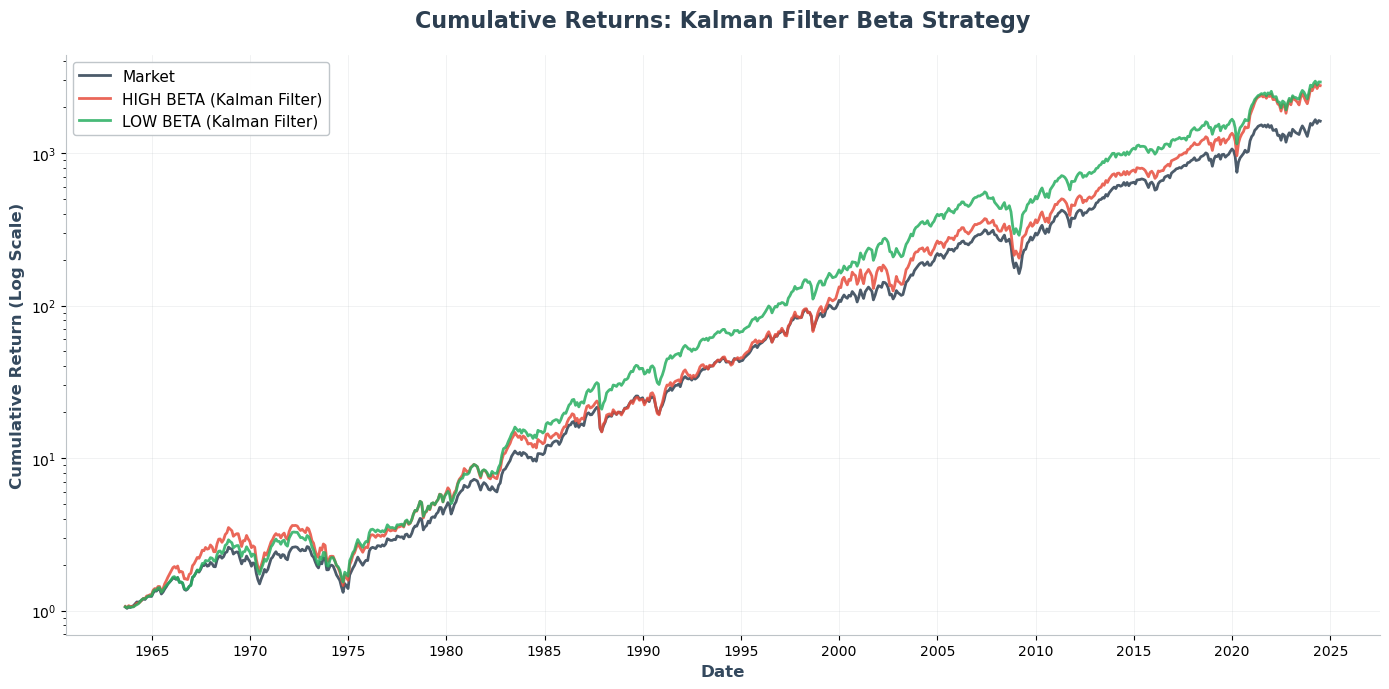


📊 CAGR :
   • HIGH BETA (Kalman) : 13.92% per year
   • LOW BETA (Kalman)  : 14.02% per year

✅ NOTEBOOK 5 TERMINÉ

📌 EXPECTED RESULTS :
   • Turnover : Similar to EWMA (optimal smoothness)
   • Performance : Slightly better risk-adjusted (statistically optimal)
   • Trade-off : Kalman = Best theoretical properties, more computation


In [10]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 7 : VISUALIZATION
# ════════════════════════════════════════════════════════════════════════════

print("="*100)
print("📈 VISUALISATION")
print("="*100)

cumret = (1 + df_output[['Market', 'HIGH_BETA_KALMAN', 'LOW_BETA_KALMAN']].dropna()).cumprod()

fig, ax = plt.subplots(figsize=(14, 7), facecolor='white')

ax.plot(cumret.index, cumret['Market'], color='#2C3E50', linewidth=2.0, label='Market', alpha=0.85)
ax.plot(cumret.index, cumret['HIGH_BETA_KALMAN'], color='#E74C3C', linewidth=2.0, label='HIGH BETA (Kalman Filter)', alpha=0.85)
ax.plot(cumret.index, cumret['LOW_BETA_KALMAN'], color='#27AE60', linewidth=2.0, label='LOW BETA (Kalman Filter)', alpha=0.85)

ax.set_title('Cumulative Returns: Kalman Filter Beta Strategy', fontsize=16, fontweight='bold', color='#2C3E50', pad=20)
ax.set_xlabel('Date', fontsize=12, fontweight='600', color='#34495E')
ax.set_ylabel('Cumulative Return (Log Scale)', fontsize=12, fontweight='600', color='#34495E')
ax.set_yscale('log')

ax.grid(True, which='major', linestyle='-', linewidth=0.5, color='#BDC3C7', alpha=0.3)
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax.legend(loc='upper left', frameon=True, shadow=False, framealpha=0.95, edgecolor='#BDC3C7', fontsize=11)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#BDC3C7')
ax.spines['bottom'].set_color('#BDC3C7')

plt.tight_layout()
plt.show()

n_years = (cumret.index[-1] - cumret.index[0]).days / 365.25
cagr_high = (cumret['HIGH_BETA_KALMAN'].iloc[-1] ** (1/n_years)) - 1
cagr_low = (cumret['LOW_BETA_KALMAN'].iloc[-1] ** (1/n_years)) - 1

print(f"\n📊 CAGR :")
print(f"   • HIGH BETA (Kalman) : {cagr_high*100:.2f}% per year")
print(f"   • LOW BETA (Kalman)  : {cagr_low*100:.2f}% per year")

print("\n" + "="*100)
print("✅ NOTEBOOK 5 TERMINÉ")
print("="*100)
print("\n📌 EXPECTED RESULTS :")
print("   • Turnover : Similar to EWMA (optimal smoothness)")
print("   • Performance : Slightly better risk-adjusted (statistically optimal)")
print("   • Trade-off : Kalman = Best theoretical properties, more computation")
print("="*100)